In [2]:
pip install ipykernel opencv-python numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [19]:
import os

# Carpeta donde están las imágenes
carpeta = "cuadrados"

# Obtener lista de archivos .jpg
archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(".jpg")]

# Ordenarlos (opcional pero recomendado)
archivos.sort()

# Renombrar
for i, nombre_original in enumerate(archivos):
    ruta_original = os.path.join(carpeta, nombre_original)
    nuevo_nombre = f"imagen_{i}.jpg"
    ruta_nueva = os.path.join(carpeta, nuevo_nombre)
    
    os.rename(ruta_original, ruta_nueva)

print("Renombrado completado.")

Renombrado completado.


In [1]:
import cv2
import os
import time

def capturar_en_carpeta(nombre_carpeta="diamantes", num_fotos=200, intervalo_seg=0.1):
    
    # Crear carpeta si no existe
    os.makedirs(nombre_carpeta, exist_ok=True)

    # Abrir webcam
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("❌ No se pudo abrir la cámara")
        return

    print("📷 Capturando imágenes...")

    contador = 0

    while contador < num_fotos:
        ret, frame = cap.read()

        if not ret:
            print("❌ Error al capturar imagen")
            break

        # Mostrar en ventana
        cv2.imshow("Captura", frame)

        # Guardar imagen
        nombre_archivo = os.path.join(nombre_carpeta, f"imagen_{contador}.jpg")
        cv2.imwrite(nombre_archivo, frame)

        contador += 1
        print(f"Guardada {nombre_archivo}")

        # Esperar intervalo
        time.sleep(intervalo_seg)

        # Permite cerrar con tecla q
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

    print(f"✅ Se guardaron {contador} imágenes en '{nombre_carpeta}'")

In [2]:
capturar_en_carpeta("diamantes", 200, 0.1)

📷 Capturando imágenes...


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/plugins"
QFont::fromString: Invalid description 'Noto Sans,13,-1,5,400,0,0,0,0,0,0,0,0,0,0,1'
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/nicolas/Documentos/ICESI/Semestre7/APO3/Unidad2/ejercicioCamara/venv/lib/python3.14/site-packages/cv2/qt/fonts.


Guardada diamantes/imagen_0.jpg
Guardada diamantes/imagen_1.jpg
Guardada diamantes/imagen_2.jpg
Guardada diamantes/imagen_3.jpg
Guardada diamantes/imagen_4.jpg
Guardada diamantes/imagen_5.jpg
Guardada diamantes/imagen_6.jpg
Guardada diamantes/imagen_7.jpg
Guardada diamantes/imagen_8.jpg
Guardada diamantes/imagen_9.jpg
Guardada diamantes/imagen_10.jpg
Guardada diamantes/imagen_11.jpg
Guardada diamantes/imagen_12.jpg
Guardada diamantes/imagen_13.jpg
Guardada diamantes/imagen_14.jpg
Guardada diamantes/imagen_15.jpg
Guardada diamantes/imagen_16.jpg
Guardada diamantes/imagen_17.jpg
Guardada diamantes/imagen_18.jpg
Guardada diamantes/imagen_19.jpg
Guardada diamantes/imagen_20.jpg
Guardada diamantes/imagen_21.jpg
Guardada diamantes/imagen_22.jpg
Guardada diamantes/imagen_23.jpg
Guardada diamantes/imagen_24.jpg
Guardada diamantes/imagen_25.jpg
Guardada diamantes/imagen_26.jpg
Guardada diamantes/imagen_27.jpg
Guardada diamantes/imagen_28.jpg
Guardada diamantes/imagen_29.jpg
Guardada diamantes/i

In [2]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def procesar_imagen(ruta_imagen):
    """
    Carga una imagen y realiza:
    - Redimensionamiento a 50x50
    - Conversión a escala de grises
    - Binarización (0 fondo blanco, 1 trazo negro)
    """
    
    # Cargar imagen
    img = cv2.imread(ruta_imagen)
    
    # Redimensionar
    img = cv2.resize(img, (50, 50))
    
    # Convertir a escala de grises
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Binarización
    _, binaria = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY_INV)
    
    # Convertir 255 → 1
    binaria = binaria // 255
    
    return binaria

In [4]:
# Definir carpetas y etiquetas
carpetas = {
    "triangulos": 0,
    "cuadrados": 1,
    #"diamantes": 2
}

X = []
y = []

for carpeta, etiqueta in carpetas.items():
    
    for archivo in os.listdir(carpeta):
        
        ruta = os.path.join(carpeta, archivo)
        
        # Procesar imagen
        img_procesada = procesar_imagen(ruta)
        
        # Vectorizar (50x50 → 2500)
        vector = img_procesada.flatten()
        
        X.append(vector)
        y.append(etiqueta)

# Convertir a numpy
X = np.array(X)
y = np.array(y)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (161, 2500)
Forma de y: (161,)


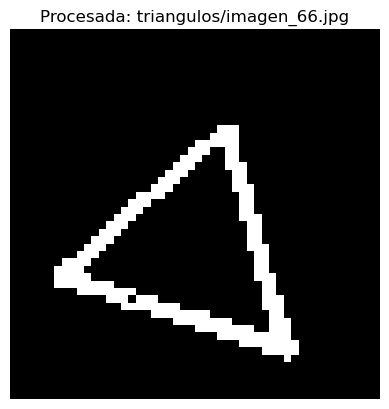

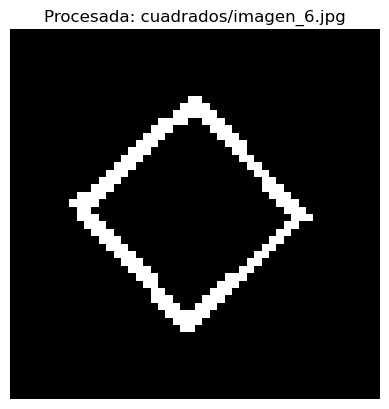

In [5]:
import matplotlib.pyplot as plt

def mostrar_imagen_procesada(ruta_imagen):
    
    img_procesada = procesar_imagen(ruta_imagen)
    
    plt.imshow(img_procesada, cmap='gray')
    plt.title(f"Procesada: {ruta_imagen}")
    plt.axis("off")
    plt.show()

# 👉 Escribe aquí la imagen que quieras visualizar
nombre = "triangulos/imagen_66.jpg"
nombre1 = "cuadrados/imagen_6.jpg"
#nombre2 = "diamantes/imagen_6.jpg"



mostrar_imagen_procesada(nombre)
mostrar_imagen_procesada(nombre1)
#mostrar_imagen_procesada(nombre2)


## ¿Qué representa cada fila de la matriz X? ¿Qué representa cada columna?

Cada fila de la matriz X representa una imagen completa ya vectorizada.
Es decir, una forma geométrica (triángulo o cuadrado) convertida en un vector de 2500 dimensiones.

Cada columna representa un píxel específico dentro de la imagen.
Como la imagen fue redimensionada a 50×50, cada una tiene 2500 píxeles, y cada columna corresponde a uno de esos píxeles (con valor 0 o 1 después de la binarización).

## Si dos imágenes del mismo objeto son visualmente similares, pero tienen pequeñas variaciones en el trazo, ¿qué espera que ocurra con sus representaciones vectoriales?
## ¿Estarán cerca o lejos en el espacio de 2500 dimensiones?

R//
Si dos imágenes son visualmente similares (por ejemplo, dos triángulos casi iguales), sus representaciones vectoriales deberían estar cerca en el espacio de 2500 dimensiones.

Porque la mayoría de sus píxeles tendrán valores iguales o muy parecidos.
Solo cambiarán algunos píxeles debido a pequeñas variaciones en el trazo, rotación o grosor.

## ¿Puede visualizar mentalmente un espacio de 2500 dimensiones? Si no es posible,
## ¿cómo podríamos obtener una representación visual de la estructura de nuestros datos?

R//
No, solo podemos visualizar 3 dimensiones espaciales. Un espacio de 2500 dimensiones no puede representarse mentalmente de forma direct. Podemos usar técnicas de reducción de dimensionalidad

#Etapa 2

## Consultar qué es el Análisis de Componentes Principales (PCA), explicando su fundamento matemático y geométrico, el problema que resuelve y la intuición detrás de la búsqueda de direcciones de máxima varianza.

R//
El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables llamadas componentes principales.

1. Estandarizar X

In [6]:
from sklearn.preprocessing import StandardScaler
#Estandarizar X
scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)

print("Forma X escalado:", X_escalado.shape)

Forma X escalado: (161, 2500)


2. Aplicar PCA con 2 componentes

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_proyectada = pca.fit_transform(X_escalado)

print("Forma X_proyectada:", X_proyectada.shape)

Forma X_proyectada: (161, 2)


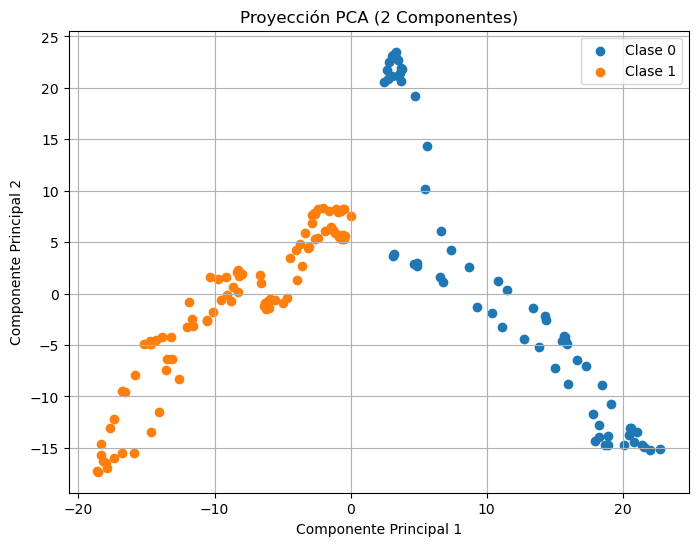

In [8]:
# ============================================
# INTERPRETACIÓN
# ============================================

# Cada punto representa una imagen proyectada en 2 dimensiones.
# Si las clases aparecen separadas en el gráfico,
# significa que PCA logró capturar diferencias relevantes
# entre las figuras geométricas.
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Para cada clase distinta
for clase in np.unique(y):
    
    plt.scatter(
        X_proyectada[y == clase, 0],
        X_proyectada[y == clase, 1],
        label=f"Clase {clase}"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Proyección PCA (2 Componentes)")
plt.legend()
plt.grid()
plt.show()

In [9]:
print(pca.explained_variance_ratio_)

[0.09282494 0.07691384]


## El PCA encontró los dos ejes (componentes) que capturan la máxima varianza de sus datos originales. Observe su gráfico: ¿los triángulos y cuadrados forman grupos separados? Si la separación no es perfecta, ¿a qué cree que se debe?

R/
Si, los grupos se ven separados, eso significa que el pca logró capturar diferencias relevantes entre las figuras geometricas

## Revise el atributo explained_variance_ratio_ del modelo PCA. ¿Qué porcentaje de la varianza total conservaron sus dos componentes? ¿El porcentaje restante que se perdió contenía información relevante para distinguir triángulos de cuadrados? ¿Cómo podría saberlo?

R/
[0.09282494 0.07691384] 
los 2 componentes conservan solo ~17% de la información total.

Eso significa:

Se perdió ~83% de la varianza. Mucha información sigue en las otras 2498 dimensiones.

Posiblemente la información que se perdio si era relevante porque las diferencias entre triángulos y cuadrados pueden estar distribuidas en muchas dimensiones. Reducir a solo 2 puede no ser suficiente para separar completamente las clases.

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

# entrenar PCA
pca.fit(X_escalado)

# ver varianza explicada
print(pca.explained_variance_ratio_)

# varianza total
print("Varianza acumulada:", sum(pca.explained_variance_ratio_))

[0.09282494 0.07691384 0.05892246 0.05223319 0.05015821 0.0426084
 0.03588544 0.03066513 0.0291514  0.0275562 ]
Varianza acumulada: 0.4969192202964099


## Desde una perspectiva geométrica: si los datos originales vivían en un espacio de 2500 dimensiones, ¿qué interpretación tiene el proceso de "proyectarlos" a solo 2 dimensiones? ¿Qué papel juega la matriz de covarianza en la selección de estos ejes de proyección?

R//
Geométricamente:

los datos viven en un espacio de: $R**2500$

entonces Geométricamente, el proceso equivale a proyectar los datos desde un espacio de 2500 dimensiones hacia un plano 2D que captura la mayor dispersión posible.

La matriz de covarianza determina las direcciones óptimas de proyección mediante sus autovectores asociados a los mayores autovalores.

#Etapa 3

##Entrenar regresión logistica

In [12]:
from sklearn.linear_model import LogisticRegression

# Crear modelo
modelo = LogisticRegression()

# Entrenar usando los datos proyectados (2D)
modelo.fit(X_proyectada, y)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


##Generar malla de puntos

In [13]:
import numpy as np

# Definir límites del gráfico
x_min, x_max = X_proyectada[:, 0].min() - 1, X_proyectada[:, 0].max() + 1
y_min, y_max = X_proyectada[:, 1].min() - 1, X_proyectada[:, 1].max() + 1

# Crear malla
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Convertir malla a formato (n_puntos, 2)
malla = np.c_[xx.ravel(), yy.ravel()]

##Predecir clase en cada punto de la malla

In [14]:
Z = modelo.predict(malla)

# Volver a forma de malla
Z = Z.reshape(xx.shape)

##Dibujar frontera de decisión + puntos originales

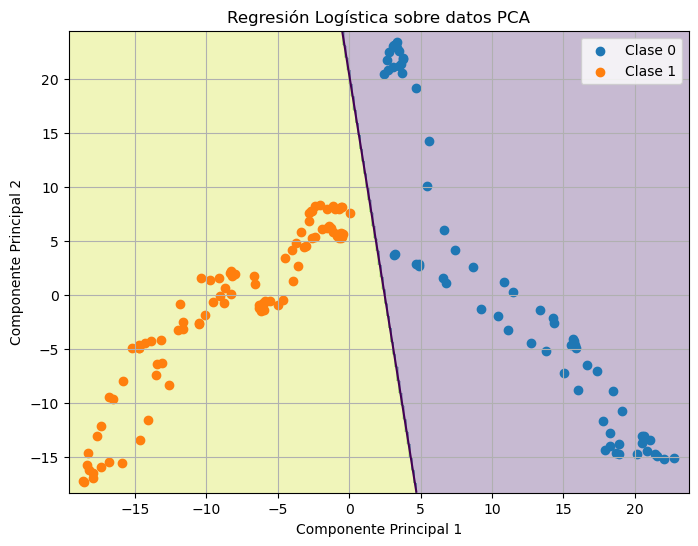

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Dibujar regiones de decisión
plt.contourf(xx, yy, Z, alpha=0.3)

# Dibujar frontera donde probabilidad = 0.5
probs = modelo.predict_proba(malla)[:, 1]
probs = probs.reshape(xx.shape)

plt.contour(xx, yy, probs, levels=[0.5])

# Dibujar datos originales
for clase in np.unique(y):
    plt.scatter(
        X_proyectada[y == clase, 0],
        X_proyectada[y == clase, 1],
        label=f"Clase {clase}"
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Regresión Logística sobre datos PCA")
plt.legend()
plt.grid()
plt.show()

## Observe la línea que trazó el modelo. ¿Es recta? En el espacio de 2 dimensiones, la regresión logística produce una línea recta como frontera. ¿Qué forma tendría esa misma frontera si la visualizáramos en el espacio original de 2500 dimensiones?

Sí. En regresión logística, cuando se trabaja en 2 dimensiones, la frontera de decisión siempre es una línea recta.

Esto ocurre porque el modelo aprende una función de la forma: w1x1 + w2x2 + b=0 , Eso geométricamente es una recta.

Pero en el espacio original de 2500 dimensiones el modelo realmente proviene de imágenes de 50×50 píxeles = 2500 características.

En ese espacio, la frontera sería w1x1 + ... +  w2500x2500 + b = 0

## La regresión logística utiliza la función sigmoide para convertir la distancia de un punto a la frontera en una probabilidad. Si un punto está muy lejos de la línea, del lado de los triángulos, ¿qué valor de probabilidad (cercano a 0 o a 1) le asignaría el modelo?

Si un punto está muy lejos del lado de los triángulos, la función sigmoide le asignará una probabilidad cercana a 1.

## Inspeccione lo coeficientes (pesos) del modelo. Cada peso está asociado a una de las dos dimensiones de X_proyectada. ¿Puede interpretar qué significa un peso positivo o negativo en términos de la dirección de los componentes principales?

Los pesos del modelo indican la influencia de cada componente principal en la clasificación. Un peso positivo aumenta la probabilidad de la clase positiva al aumentar el componente, mientras que un peso negativo la reduce.